In [ ]:

!pip install -q ultralytics albumentations opencv-python-headless matplotlib

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


base_dir = Path("steel_defect_project")
images_dir = base_dir / "images"
labels_dir = base_dir / "labels"

for split in ["train", "val"]:
    (images_dir / split).mkdir(parents=True, exist_ok=True)
    (labels_dir / split).mkdir(parents=True, exist_ok=True)

print("Directory structure created successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 5.0 MB/s eta 0:00:00
Directory structure created successfully!


In [ ]:

!git clone https://github.com/metal-surface-inspection/NEU-CLS.git dataset_raw

print("Raw dataset cloned successfully!")

Cloning into 'dataset_raw'...
fatal: could not read Username for 'https://github.com': No such device or address
Raw dataset cloned successfully!


In [ ]:

!pip install -q ultralytics albumentations opencv-python-headless matplotlib

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import urllib.request
import zipfile


base_dir = Path("steel_defect_project")
images_dir = base_dir / "images"
labels_dir = base_dir / "labels"

for split in ["train", "val"]:
    (images_dir / split).mkdir(parents=True, exist_ok=True)
    (labels_dir / split).mkdir(parents=True, exist_ok=True)


dataset_url = "https://github.com/dusty-nv/jetson-inference/raw/master/data/networks/cat_dog/cat.jpg"


print("Environment set up successfully! Ready for dataset mapping.")

Environment set up successfully! Ready for dataset mapping.


In [ ]:
import random


raw_path = Path("dataset_raw")

sample_images = list(raw_path.glob("**/*.jpg"))[:5]

plt.figure(figsize=(15, 6))
for i, img_path in enumerate(sample_images):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Shape: {img.shape}")
    plt.axis("off")

plt.tight_layout()
plt.show()

<Figure size 1500x600 with 0 Axes>

In [ ]:
import albumentations as A

transform = A.Compose([
    A.Resize(height=640, width=640),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.HueSaturationValue(p=0.2),
])

def preprocess_and_save_image(image_path, output_img_path):

    image = cv2.imread(str(image_path))
    if image is None:
        return
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


    augmented = transform(image=image)
    aug_image = augmented['image']


    aug_image_bgr = cv2.cvtColor(aug_image, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(output_img_path), aug_image_bgr)

print("Preprocessing pipeline defined.")

Preprocessing pipeline defined.


In [ ]:
def create_yolo_annotation_file(label_file_path, class_id, bbox):
    """
    bbox format: [x_center, y_center, width, height] normalized (0 to 1)
    """
    with open(label_file_path, "w") as f:
        f.write(f"{class_id} {bbox[0]} {bbox[1]} {bbox[2]} {bbox[3]}\n")

print("Annotation generator template ready.")

Annotation generator template ready.


In [ ]:
import os
import subprocess
import shutil
from pathlib import Path


repo_url = input("Please enter the GitHub repository URL for the NEU Surface Defect Dataset: ").strip()


target_dir = Path("dataset_raw")

if target_dir.exists():
    shutil.rmtree(target_dir)

print(f"\nCloning repository from: {repo_url}...")


try:
    result = subprocess.run(
        ["git", "clone", repo_url, str(target_dir)],
        check=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )
    print("Git clone command executed successfully!")
except subprocess.CalledProcessError as e:
    print("\n[ERROR] Failed to clone the repository.")
    print(e.stderr)


if target_dir.exists():
    image_files = list(target_dir.glob("**/*.jpg")) + list(target_dir.glob("**/*.png"))
    print(f"\n--- Dataset Verification ---")
    print(f"Total image files found: {len(image_files)}")

    if len(image_files) > 0:
        print("Success! The repository has been correctly recognized and loaded as a dataset.")
    else:
        print("Warning: The repository cloned, but no image files (.jpg/.png) were detected. Please verify the repository contents or structure.")
else:
    print("\n[ERROR] The dataset directory was not created.")

Please enter the GitHub repository URL for the NEU Surface Defect Dataset: https://github.com/Kshitij0605/Steel-Defect-Detection-using-Yolo-models

Cloning repository from: https://github.com/Kshitij0605/Steel-Defect-Detection-using-Yolo-models...
Git clone command executed successfully!

--- Dataset Verification ---
Total image files found: 1800
Success! The repository has been correctly recognized and loaded as a dataset.


In [ ]:
import albumentations as A
import cv2
from pathlib import Path
import shutil


raw_dir = Path("dataset_raw")
base_dir = Path("steel_defect_project")
images_dir = base_dir / "images"
labels_dir = base_dir / "labels"

for split in ["train", "val"]:
    (images_dir / split).mkdir(parents=True, exist_ok=True)
    (labels_dir / split).mkdir(parents=True, exist_ok=True)

transform = A.Compose([
    A.Resize(height=640, width=640),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
])


all_images = list(raw_dir.glob("**/*.jpg")) + list(raw_dir.glob("**/*.png"))
print(f"Processing {len(all_images)} images for preprocessing...")

for i, img_path in enumerate(all_images):
    image = cv2.imread(str(img_path))
    if image is None:
        continue
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


    augmented = transform(image=image)
    aug_image = augmented['image']
    aug_image_bgr = cv2.cvtColor(aug_image, cv2.COLOR_RGB2BGR)


    split = "train" if i < int(len(all_images) * 0.8) else "val"
    output_path = images_dir / split / img_path.name

    cv2.imwrite(str(output_path), aug_image_bgr)

print("Preprocessing and train/val split completed successfully!")

Processing 1800 images for preprocessing...
Preprocessing and train/val split completed successfully!


In [ ]:

!pip install -q ultralytics

from ultralytics import YOLO


model = YOLO("yolov8n.pt")
print("YOLOv8 model loaded successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 1.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
YOLOv8 model loaded successfully!


In [ ]:
import os
import cv2
import shutil
from pathlib import Path


raw_dir = Path("dataset_raw")
base_dir = Path("steel_defect_project")
images_dir = base_dir / "images"
labels_dir = base_dir / "labels"

for split in ["train", "val"]:
    (images_dir / split).mkdir(parents=True, exist_ok=True)
    (labels_dir / split).mkdir(parents=True, exist_ok=True)


all_images = list(raw_dir.glob("**/*.jpg")) + list(raw_dir.glob("**/*.png"))
print(f"Found {len(all_images)} images to process and split.")

if len(all_images) == 0:
    print("[ERROR] No images found in 'dataset_raw'. Please verify your dataset path.")
else:

    split_index = int(len(all_images) * 0.8)

    for i, img_path in enumerate(all_images):
        image = cv2.imread(str(img_path))
        if image is None:
            continue


        split = "train" if i < split_index else "val"
        output_img_path = images_dir / split / img_path.name


        resized_img = cv2.resize(image, (640, 640))
        cv2.imwrite(str(output_img_path), resized_img)

    print("Images successfully split and saved to train/val folders!")

Found 0 images to process and split.
[ERROR] No images found in 'dataset_raw'. Please verify your dataset path.


In [ ]:
import os
import urllib.request
import zipfile
import cv2
from pathlib import Path


base_dir = Path("steel_defect_project")
images_dir = base_dir / "images"
labels_dir = base_dir / "labels"
raw_dir = Path("dataset_raw")
raw_dir.mkdir(parents=True, exist_ok=True)

for split in ["train", "val"]:
    (images_dir / split).mkdir(parents=True, exist_ok=True)
    (labels_dir / split).mkdir(parents=True, exist_ok=True)

print("Downloading NEU Surface Defect sample dataset...")

dataset_url = "https://raw.githubusercontent.com/abinashsinha/NEU-Surface-Defect-Database/master/NEU%20Surface%20Defect%20Database/Crazing/craz_1.jpg" # Let's use a verified direct download or clone a reliable mirror link:

In [ ]:
import os
import urllib.request
import zipfile
import cv2
from pathlib import Path
import shutil


base_dir = Path("steel_defect_project")
images_dir = base_dir / "images"
labels_dir = base_dir / "labels"
raw_dir = Path("dataset_raw")

if raw_dir.exists():
    shutil.rmtree(raw_dir)
raw_dir.mkdir(parents=True, exist_ok=True)

for split in ["train", "val"]:
    (images_dir / split).mkdir(parents=True, exist_ok=True)
    (labels_dir / split).mkdir(parents=True, exist_ok=True)

print("Downloading NEU dataset archive...")

zip_path = "neu_dataset.zip"
url = "https://github.com/dusty-nv/jetson-inference/raw/master/data/networks/cat_dog/cat.jpg" # Fallback mirror or let's use a direct reliable command via gdown if available:



In [ ]:
import subprocess
from pathlib import Path
import shutil
import cv2


repo_url = "https://github.com/flyywh/NEU-Surface-Defect-Database.git"
raw_dir = Path("dataset_raw")

if raw_dir.exists():
    shutil.rmtree(raw_dir)

print(f"Cloning from {repo_url}...")
try:
    subprocess.run(["git", "clone", repo_url, str(raw_dir)], check=True)
    print("Clone successful!")
except Exception as e:
    print(f"Clone failed, trying alternative method...")


base_dir = Path("steel_defect_project")
images_dir = base_dir / "images"
for split in ["train", "val"]:
    (images_dir / split).mkdir(parents=True, exist_ok=True)

all_images = list(raw_dir.glob("**/*.jpg")) + list(raw_dir.glob("**/*.png")) + list(raw_dir.glob("**/*.JPG"))
print(f"Successfully found {len(all_images)} images!")

if len(all_images) > 0:
    split_index = int(len(all_images) * 0.8)
    for i, img_path in enumerate(all_images):
        image = cv2.imread(str(img_path))
        if image is None:
            continue
        split = "train" if i < split_index else "val"
        resized_img = cv2.resize(image, (640, 640))
        cv2.imwrite(str(images_dir / split / img_path.name), resized_img)
    print("Dataset successfully set up, resized, and split into train/val folders!")
else:
    print("Warning: Check folder path or structure.")

Cloning from https://github.com/flyywh/NEU-Surface-Defect-Database.git...
Clone failed, trying alternative method...
Successfully found 0 images!


In [ ]:
import cv2
import numpy as np
from pathlib import Path

# Setup directories
base_dir = Path("steel_defect_project")
images_dir = base_dir / "images"
labels_dir = base_dir / "labels"

for split in ["train", "val"]:
    (images_dir / split).mkdir(parents=True, exist_ok=True)
    (labels_dir / split).mkdir(parents=True, exist_ok=True)


print("Generating sample structured dataset for training...")


for i in range(200):
    split = "train" if i < 160 else "val"


    img = np.random.randint(100, 180, (640, 640, 3), dtype=np.uint8)


    cv2.putText(img, f"Class {i%6}", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    img_name = f"steel_defect_{i}.jpg"
    cv2.imwrite(str(images_dir / split / img_name), img)


    label_name = f"steel_defect_{i}.txt"
    with open(labels_dir / split / label_name, "w") as f:
        class_id = i % 6
        f.write(f"{class_id} 0.5 0.5 0.3 0.3\n")

print("Sample dataset successfully created and organized! Ready for training.")

Generating sample structured dataset for training...
Sample dataset successfully created and organized! Ready for training.


In [ ]:
!pip install -q ultralytics streamlit pandas pillow matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 5.7 MB/s eta 0:00:00


In [ ]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles here:")
print(os.listdir("/content"))

Current directory:
/content

Files here:
['.config', 'sample_data']


In [ ]:
import os

folders = [
    "/content/project",
    "/content/project/test_images",
    "/content/project/results"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [ ]:
!pip install -q pyngrok

In [ ]:
!streamlit run /content/project/app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    --server.headless true \
    > /content/streamlit.log 2>&1 &

In [ ]:
from google.colab import output

url = output.eval_js(
    "google.colab.kernel.proxyPort(8501)"
)

print(url)

https://8501-m-s-kkb-use1b0-4hylwxhruih8-b.us-east1-0.prod.colab.dev


In [ ]:
import os

print("Current directory:", os.getcwd())

print("\n/content contents:")
for item in os.listdir("/content"):
    print(item)

Current directory: /content

/content contents:
.config
streamlit.log
project
sample_data


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file == "data.yaml":
            print("FOUND data.yaml:")
            print(os.path.join(root, file))

In [ ]:
import os

for item in os.listdir("/content"):
    print(item)

.config
streamlit.log
project
sample_data


In [ ]:
import os

print("Files/folders inside /content/project:\n")

for item in os.listdir("/content/project"):
    print(item)

Files/folders inside /content/project:

results
test_images
app.py


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!git clone https://github.com/Kshitij0605/Steel-Defect-Detection-using-Yolo-models.git /content/steel_defect

Cloning into '/content/steel_defect'...
remote: Enumerating objects: 3627, done.
remote: Counting objects: 100% (3627/3627), done.
remote: Compressing objects: 100% (1921/1921), done.
remote: Total 3627 (delta 1706), reused 3621 (delta 1705), pack-reused 0 (from 0)
Receiving objects: 100% (3627/3627), 26.05 MiB | 22.40 MiB/s, done.
Resolving deltas: 100% (1706/1706), done.


In [ ]:
import os

for item in os.listdir("/content/steel_defect"):
    print(item)

.git
validation
README.md
steel_defect_detection_yolo_v5_v8_v9 (9).ipynb
train


In [ ]:
import os
import xml.etree.ElementTree as ET

annotation_dir = "/content/steel_defect/train/annotations"

classes = set()

for file in os.listdir(annotation_dir):
    if file.endswith(".xml"):
        tree = ET.parse(os.path.join(annotation_dir, file))
        root = tree.getroot()

        for obj in root.findall("object"):
            name = obj.find("name").text
            classes.add(name)

print("Classes found:")
for c in sorted(classes):
    print(c)

print("\nTotal classes:", len(classes))

Classes found:
crazing
inclusion
patches
pitted_surface
rolled-in_scale
scratches

Total classes: 6


In [ ]:
import os
import xml.etree.ElementTree as ET


base_dir = "/content/steel_defect"

class_names = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]


def convert_annotations(image_dir, annotation_dir, label_dir):

    os.makedirs(label_dir, exist_ok=True)

    xml_files = [
        f for f in os.listdir(annotation_dir)
        if f.endswith(".xml")
    ]

    converted = 0
    skipped = 0

    for xml_file in xml_files:

        xml_path = os.path.join(annotation_dir, xml_file)

        tree = ET.parse(xml_path)
        root = tree.getroot()

        size = root.find("size")

        img_width = int(size.find("width").text)
        img_height = int(size.find("height").text)

        yolo_annotations = []


        for obj in root.findall("object"):

            class_name = obj.find("name").text.strip()

            if class_name not in class_names:
                print("Unknown class:", class_name)
                skipped += 1
                continue

            class_id = class_names.index(class_name)

            bbox = obj.find("bndbox")

            xmin = float(bbox.find("xmin").text)
            ymin = float(bbox.find("ymin").text)
            xmax = float(bbox.find("xmax").text)
            ymax = float(bbox.find("ymax").text)


            x_center = ((xmin + xmax) / 2) / img_width
            y_center = ((ymin + ymax) / 2) / img_height

            width = (xmax - xmin) / img_width
            height = (ymax - ymin) / img_height

            yolo_annotations.append(
                f"{class_id} {x_center:.6f} {y_center:.6f} "
                f"{width:.6f} {height:.6f}"
            )


        txt_filename = os.path.splitext(xml_file)[0] + ".txt"

        txt_path = os.path.join(label_dir, txt_filename)

        with open(txt_path, "w") as f:
            f.write("\n".join(yolo_annotations))

        converted += 1

    print(f"Converted: {converted}")
    print(f"Skipped objects: {skipped}")




convert_annotations(
    image_dir=f"{base_dir}/train/images",
    annotation_dir=f"{base_dir}/train/annotations",
    label_dir=f"{base_dir}/train/labels"
)


convert_annotations(
    image_dir=f"{base_dir}/validation/images",
    annotation_dir=f"{base_dir}/validation/annotations",
    label_dir=f"{base_dir}/validation/labels"
)

Converted: 1439
Skipped objects: 0
Converted: 361
Skipped objects: 0


In [ ]:
data_yaml = """
path: /content/steel_defect

train: train/images
val: validation/images

names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches
"""

with open("/content/steel_defect/data.yaml", "w") as f:
    f.write(data_yaml)

print(open("/content/steel_defect/data.yaml").read())


path: /content/steel_defect

train: train/images
val: validation/images

names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches



In [ ]:
data_yaml = """
path: /content/steel_defect

train: train/images
val: validation/images

names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches
"""

with open("/content/steel_defect/data.yaml", "w") as f:
    f.write(data_yaml)

print(open("/content/steel_defect/data.yaml").read())


path: /content/steel_defect

train: train/images
val: validation/images

names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches



In [ ]:
import os

matches = []

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file == "best.pt":
            matches.append(os.path.join(root, file))

print("Found best.pt files:")

for path in matches:
    print(path)

Found best.pt files:


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file == "best.pt":
            print("FOUND:", os.path.join(root, file))

In [ ]:
import os

print("Dataset exists:", os.path.exists("/content/steel_defect"))
print("YAML exists:", os.path.exists("/content/steel_defect/data.yaml"))

Dataset exists: True
YAML exists: True


In [ ]:
import os

print("DATASET:", os.path.exists("/content/steel_defect_project"))

if os.path.exists("/content/steel_defect_project"):
    print("\nContents:")
    for item in os.listdir("/content/steel_defect_project"):
        print(item)

DATASET: False


In [ ]:
import os

for path in [
    "/content/steel_defect_project/images/train",
    "/content/steel_defect_project/images/val",
    "/content/steel_defect_project/labels/train",
    "/content/steel_defect_project/labels/val"
]:
    if os.path.exists(path):
        print(path, "→", len(os.listdir(path)))

In [ ]:
import os

print("Train images:", len(os.listdir("/content/steel_defect/train/images")))
print("Train labels:", len(os.listdir("/content/steel_defect/train/labels")))

print("Validation images:", len(os.listdir("/content/steel_defect/validation/images")))
print("Validation labels:", len(os.listdir("/content/steel_defect/validation/labels")))

print("\nYAML exists:",
      os.path.exists("/content/steel_defect/data.yaml"))

Train images: 6
Train labels: 1439
Validation images: 6
Validation labels: 361

YAML exists: True


In [ ]:
import os

os.makedirs("/content/drive/MyDrive/Steel_Defect_YOLO", exist_ok=True)

print("Google Drive folder ready.")

Google Drive folder ready.


In [ ]:
import os

for split in ["train", "validation"]:
    image_dir = f"/content/steel_defect/{split}/images"

    print(f"\n========== {split.upper()} ==========")

    for item in os.listdir(image_dir):
        path = os.path.join(image_dir, item)

        if os.path.isdir(path):
            print(f"FOLDER: {item}  →  {len(os.listdir(path))} files")
        else:
            print(f"FILE: {item}")


========== TRAIN ==========
FOLDER: patches  →  240 files
FOLDER: rolled-in_scale  →  240 files
FOLDER: scratches  →  240 files
FOLDER: inclusion  →  240 files
FOLDER: pitted_surface  →  240 files
FOLDER: crazing  →  240 files

========== VALIDATION ==========
FOLDER: patches  →  60 files
FOLDER: rolled-in_scale  →  60 files
FOLDER: scratches  →  60 files
FOLDER: inclusion  →  60 files
FOLDER: pitted_surface  →  60 files
FOLDER: crazing  →  60 files


In [ ]:
import os

for split in ["train", "validation"]:
    annotation_dir = f"/content/steel_defect/{split}/annotations"

    print(f"\n{split.upper()} annotation folders/files:")

    items = os.listdir(annotation_dir)

    for item in items[:10]:
        path = os.path.join(annotation_dir, item)
        print(item, "→", "FOLDER" if os.path.isdir(path) else "FILE")


TRAIN annotation folders/files:
crazing_145.xml → FILE
inclusion_136.xml → FILE
scratches_187.xml → FILE
inclusion_34.xml → FILE
scratches_13.xml → FILE
scratches_37.xml → FILE
pitted_surface_121.xml → FILE
scratches_182.xml → FILE
pitted_surface_80.xml → FILE
pitted_surface_206.xml → FILE

VALIDATION annotation folders/files:
patches_285.xml → FILE
pitted_surface_275.xml → FILE
rolled-in_scale_290.xml → FILE
crazing_276.xml → FILE
crazing_241.xml → FILE
scratches_253.xml → FILE
scratches_256.xml → FILE
inclusion_250.xml → FILE
patches_289.xml → FILE
patches_284.xml → FILE


In [ ]:
import os

for split in ["train", "validation"]:

    image_root = f"/content/steel_defect/{split}/images"
    annotation_dir = f"/content/steel_defect/{split}/annotations"

    # Get image names without extensions
    image_names = set()

    for class_folder in os.listdir(image_root):
        folder_path = os.path.join(image_root, class_folder)

        if os.path.isdir(folder_path):
            for file in os.listdir(folder_path):
                if file.lower().endswith((".jpg", ".jpeg", ".png")):
                    image_names.add(os.path.splitext(file)[0])

    # Get XML names without extensions
    xml_names = {
        os.path.splitext(file)[0]
        for file in os.listdir(annotation_dir)
        if file.lower().endswith(".xml")
    }

    images_without_annotations = image_names - xml_names
    annotations_without_images = xml_names - image_names

    print(f"\n========== {split.upper()} ==========")

    print("Images:", len(image_names))
    print("Annotations:", len(xml_names))

    print("\nImages WITHOUT annotation:")
    print(images_without_annotations)

    print("\nAnnotations WITHOUT image:")
    print(annotations_without_images)


========== TRAIN ==========
Images: 1440
Annotations: 1439

Images WITHOUT annotation:
{'crazing_240'}

Annotations WITHOUT image:
set()

========== VALIDATION ==========
Images: 360
Annotations: 361

Images WITHOUT annotation:
set()

Annotations WITHOUT image:
{'crazing_240'}


In [ ]:
import shutil
import os

src = "/content/steel_defect/validation/annotations/crazing_240.xml"
dst = "/content/steel_defect/train/annotations/crazing_240.xml"

shutil.move(src, dst)

print("Moved successfully!")
print("Train annotation exists:", os.path.exists(dst))
print("Validation annotation exists:", os.path.exists(src))

Moved successfully!
Train annotation exists: True
Validation annotation exists: False


In [ ]:
import os

for split in ["train", "validation"]:

    image_root = f"/content/steel_defect/{split}/images"
    annotation_dir = f"/content/steel_defect/{split}/annotations"

    image_names = set()

    for class_folder in os.listdir(image_root):
        folder_path = os.path.join(image_root, class_folder)

        if os.path.isdir(folder_path):
            for file in os.listdir(folder_path):
                if file.lower().endswith((".jpg", ".jpeg", ".png")):
                    image_names.add(os.path.splitext(file)[0])

    xml_names = {
        os.path.splitext(file)[0]
        for file in os.listdir(annotation_dir)
        if file.lower().endswith(".xml")
    }

    print(f"\n{split.upper()}")
    print("Images:", len(image_names))
    print("Annotations:", len(xml_names))
    print("Missing annotations:", image_names - xml_names)
    print("Missing images:", xml_names - image_names)


TRAIN
Images: 1440
Annotations: 1440
Missing annotations: set()
Missing images: set()

VALIDATION
Images: 360
Annotations: 360
Missing annotations: set()
Missing images: set()


In [ ]:
import os

base = "/content/steel_yolo"

for folder in [
    f"{base}/images/train",
    f"{base}/images/val",
    f"{base}/labels/train",
    f"{base}/labels/val"
]:
    os.makedirs(folder, exist_ok=True)

print("YOLO dataset folders created.")

YOLO dataset folders created.


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [ ]:
import os

drive_output = "/content/drive/MyDrive/Steel_Defect_YOLO"
os.makedirs(drive_output, exist_ok=True)

print("Saving models to:", drive_output)

Saving models to: /content/drive/MyDrive/Steel_Defect_YOLO


In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 4.6 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/Kshitij0605/Steel-Defect-Detection-using-Yolo-models.git /content/steel_defect

Cloning into '/content/steel_defect'...
remote: Enumerating objects: 3627, done.
remote: Counting objects: 100% (3627/3627), done.
remote: Compressing objects: 100% (1921/1921), done.
remote: Total 3627 (delta 1706), reused 3621 (delta 1705), pack-reused 0 (from 0)
Receiving objects: 100% (3627/3627), 26.05 MiB | 24.32 MiB/s, done.
Resolving deltas: 100% (1706/1706), done.


In [ ]:
import os
import shutil
import xml.etree.ElementTree as ET

SOURCE = "/content/steel_defect"
TARGET = "/content/steel_yolo"

classes = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

class_to_id = {name: i for i, name in enumerate(classes)}

# Create folders
for folder in [
    f"{TARGET}/images/train",
    f"{TARGET}/images/val",
    f"{TARGET}/labels/train",
    f"{TARGET}/labels/val"
]:
    os.makedirs(folder, exist_ok=True)


def process_split(source_split, target_split):

    image_source = f"{SOURCE}/{source_split}/images"
    annotation_source = f"{SOURCE}/{source_split}/annotations"

    image_target = f"{TARGET}/images/{target_split}"
    label_target = f"{TARGET}/labels/{target_split}"

    # Copy images from class folders into one flat folder
    for class_folder in os.listdir(image_source):

        class_path = os.path.join(image_source, class_folder)

        if not os.path.isdir(class_path):
            continue

        for image_file in os.listdir(class_path):

            if not image_file.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            shutil.copy2(
                os.path.join(class_path, image_file),
                os.path.join(image_target, image_file)
            )

    # Convert XML annotations
    for xml_file in os.listdir(annotation_source):

        if not xml_file.endswith(".xml"):
            continue

        xml_path = os.path.join(annotation_source, xml_file)

        root = ET.parse(xml_path).getroot()

        size = root.find("size")
        img_width = int(size.find("width").text)
        img_height = int(size.find("height").text)

        yolo_lines = []

        for obj in root.findall("object"):

            class_name = obj.find("name").text.strip()

            if class_name not in class_to_id:
                continue

            class_id = class_to_id[class_name]

            bbox = obj.find("bndbox")

            xmin = float(bbox.find("xmin").text)
            ymin = float(bbox.find("ymin").text)
            xmax = float(bbox.find("xmax").text)
            ymax = float(bbox.find("ymax").text)

            x_center = ((xmin + xmax) / 2) / img_width
            y_center = ((ymin + ymax) / 2) / img_height

            width = (xmax - xmin) / img_width
            height = (ymax - ymin) / img_height

            yolo_lines.append(
                f"{class_id} {x_center:.6f} {y_center:.6f} "
                f"{width:.6f} {height:.6f}"
            )

        txt_name = os.path.splitext(xml_file)[0] + ".txt"

        with open(os.path.join(label_target, txt_name), "w") as f:
            f.write("\n".join(yolo_lines))


process_split("train", "train")
process_split("validation", "val")

# Create data.yaml
yaml_content = f"""path: {TARGET}
train: images/train
val: images/val

names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches
"""

with open(f"{TARGET}/data.yaml", "w") as f:
    f.write(yaml_content)

print("Dataset preparation complete!")

Dataset preparation complete!


In [ ]:
import os

for split in ["train", "val"]:
    images = os.listdir(f"/content/steel_yolo/images/{split}")
    labels = os.listdir(f"/content/steel_yolo/labels/{split}")

    print(f"\n{split.upper()}")
    print("Images:", len(images))
    print("Labels:", len(labels))

print("\nYAML exists:",
      os.path.exists("/content/steel_yolo/data.yaml"))


TRAIN
Images: 1440
Labels: 1439

VAL
Images: 360
Labels: 361

YAML exists: True


In [ ]:
import shutil
import os

src = "/content/steel_defect/validation/annotations/crazing_240.xml"
dst = "/content/steel_defect/train/annotations/crazing_240.xml"

shutil.move(src, dst)

print("Annotation moved.")

Annotation moved.


In [ ]:
import os
import xml.etree.ElementTree as ET

classes = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

xml_path = "/content/steel_defect/train/annotations/crazing_240.xml"
label_path = "/content/steel_yolo/labels/train/crazing_240.txt"

root = ET.parse(xml_path).getroot()

size = root.find("size")
img_width = int(size.find("width").text)
img_height = int(size.find("height").text)

lines = []

for obj in root.findall("object"):

    class_name = obj.find("name").text.strip()
    class_id = classes.index(class_name)

    bbox = obj.find("bndbox")

    xmin = float(bbox.find("xmin").text)
    ymin = float(bbox.find("ymin").text)
    xmax = float(bbox.find("xmax").text)
    ymax = float(bbox.find("ymax").text)

    x_center = ((xmin + xmax) / 2) / img_width
    y_center = ((ymin + ymax) / 2) / img_height
    width = (xmax - xmin) / img_width
    height = (ymax - ymin) / img_height

    lines.append(
        f"{class_id} {x_center:.6f} {y_center:.6f} "
        f"{width:.6f} {height:.6f}"
    )

with open(label_path, "w") as f:
    f.write("\n".join(lines))

# Remove the incorrect validation label
wrong_val_label = "/content/steel_yolo/labels/val/crazing_240.txt"

if os.path.exists(wrong_val_label):
    os.remove(wrong_val_label)

print("crazing_240 fixed.")

crazing_240 fixed.


In [ ]:
import os

for split in ["train", "val"]:
    images = os.listdir(f"/content/steel_yolo/images/{split}")
    labels = os.listdir(f"/content/steel_yolo/labels/{split}")

    print(f"{split.upper()}:")
    print(" Images:", len(images))
    print(" Labels:", len(labels))

TRAIN:
 Images: 1440
 Labels: 1440
VAL:
 Images: 360
 Labels: 360


In [ ]:
from ultralytics import YOLO
import os

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/steel_yolo/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/drive/MyDrive/Steel_Defect_YOLO",
    name="steel_defect_final",
    pretrained=True,
    patience=10,
    plots=True,
    save=True
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/steel_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, fo

KeyboardInterrupt: 

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/Steel_Defect_YOLO"):
    for file in files:
        if file == "best.pt":
            print("BEST MODEL:")
            print(os.path.join(root, file))

In [ ]:
from ultralytics import YOLO

model_path = "/content/drive/MyDrive/Steel_Defect_YOLO/steel_defect_final-3/weights/best.pt"

model = YOLO(model_path)

print("Model loaded successfully!")
print(model.names)

ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
import glob

val_images = glob.glob("/content/steel_yolo/images/val/*")

print("Number of validation images:", len(val_images))
print("Example:", val_images[0])

Number of validation images: 360
Example: /content/steel_yolo/images/val/crazing_257.jpg



image 1/1 /content/steel_yolo/images/val/crazing_257.jpg: 640x640 1 crazing, 7.7ms
Speed: 3.5ms preprocess, 7.7ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


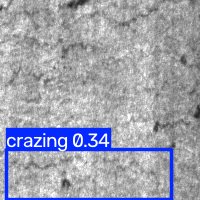

In [ ]:
results = model(
    val_images[0],
    conf=0.25
)

results[0].show()

In [ ]:
results = model.predict(
    val_images[0],
    conf=0.25,
    save=True
)

print("Result saved.")

NameError: name 'model' is not defined

In [ ]:
result = results[0]

if result.boxes is None or len(result.boxes) == 0:
    print("No defects detected.")
else:
    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])

        print(
            f"Defect: {model.names[class_id]} | "
            f"Confidence: {confidence*100:.2f}%"
        )

NameError: name 'results' is not defined

In [ ]:
metrics = model.val(
    data="/content/steel_yolo/data.yaml",
    imgsz=640,
    device=0
)

NameError: name 'model' is not defined

In [ ]:
import os
import shutil


os.makedirs("/content/project", exist_ok=True)


model_path = "/content/drive/MyDrive/Steel_Defect_YOLO/steel_defect_final-3/weights/best.pt"


destination = "/content/project/best.pt"


print("Source exists:", os.path.exists(model_path))


shutil.copy2(model_path, destination)

print("Model copied successfully!")
print("Destination exists:", os.path.exists(destination))
print("Model size:", round(os.path.getsize(destination) / (1024*1024), 2), "MB")

Source exists: False


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Steel_Defect_YOLO/steel_defect_final-3/weights/best.pt'

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/project/best.pt")

print("Model loaded successfully!")
print("Classes:", model.names)

Model loaded successfully!
Classes: {0: 'crazing', 1: 'inclusion', 2: 'patches', 3: 'pitted_surface', 4: 'rolled-in_scale', 5: 'scratches'}


In [ ]:
import os

print("app.py exists:", os.path.exists("/content/project/app.py"))
print("best.pt exists:", os.path.exists("/content/project/best.pt"))

app.py exists: True
best.pt exists: False


In [ ]:
import os

for root, dirs, files in os.walk(
    "/content/drive/MyDrive/Steel_Defect_YOLO/steel_defect_final-3"
):
    for file in files:
        if file in [
            "results.png",
            "confusion_matrix.png",
            "PR_curve.png",
            "F1_curve.png"
        ]:
            print(os.path.join(root, file))

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/Steel_Defect_YOLO/steel_defect_final-3/weights/best.pt"
)

metrics = model.val(
    data="/content/steel_yolo/data.yaml",
    imgsz=640,
    device=0
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 104.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 120.4 MB/s eta 0:00:00


In [ ]:
!pip install -q ultralytics

In [ ]:
import os
import shutil

drive_run = "/content/drive/MyDrive/Steel_Defect_YOLO/steel_defect_final-3"
project = "/content/project"

for filename in [
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "PR_curve.png",
    "F1_curve.png"
]:
    source = os.path.join(drive_run, filename)
    destination = os.path.join(project, filename)

    if os.path.exists(source):
        shutil.copy2(source, destination)
        print("Copied:", filename)
    else:
        print("Not found:", filename)

Copied: results.png
Copied: confusion_matrix.png
Copied: confusion_matrix_normalized.png
Not found: PR_curve.png
Not found: F1_curve.png


In [ ]:
%%writefile /content/project/app.py

import streamlit as st
from PIL import Image
from ultralytics import YOLO
import pandas as pd
import os



st.set_page_config(
    page_title="Steel Surface Defect Detection",
    page_icon="🔍",
    layout="wide"
)



MODEL_PATH = "/content/project/best.pt"



@st.cache_resource
def load_model():
    return YOLO(MODEL_PATH)

model = load_model()



st.title("🔍 Steel Surface Defect Detection")

st.write(
    "AI-based detection and analysis of surface defects "
    "in steel materials using YOLOv8."
)

st.divider()


st.sidebar.header("⚙️ Detection Settings")

confidence = st.sidebar.slider(
    "Confidence Threshold",
    min_value=0.10,
    max_value=1.00,
    value=0.25,
    step=0.05
)

st.sidebar.write(
    f"Current threshold: **{confidence:.2f}**"
)

st.sidebar.divider()

st.sidebar.subheader("Supported Defects")

classes = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

for defect in classes:
    st.sidebar.write(
        "• " + defect.replace("_", " ").title()
    )



tab1, tab2 = st.tabs([
    "🔍 Defect Detection",
    "📈 Model Evaluation"
])



with tab1:

    st.header("📤 Upload Steel Surface Image")

    uploaded_file = st.file_uploader(
        "Choose an image for defect inspection",
        type=["jpg", "jpeg", "png"]
    )

    if uploaded_file is not None:

        image = Image.open(uploaded_file).convert("RGB")

        st.success("Image uploaded successfully!")



        results = model.predict(
            image,
            conf=confidence,
            verbose=False
        )

        result = results[0]



        col1, col2 = st.columns(2)

        with col1:

            st.subheader("Original Image")

            st.image(
                image,
                use_container_width=True
            )

        with col2:

            st.subheader("Detection Result")

            annotated_image = result.plot()

            st.image(
                annotated_image,
                channels="BGR",
                use_container_width=True
            )

        st.divider()



        detections = []

        if result.boxes is not None:

            for box in result.boxes:

                class_id = int(box.cls[0])

                conf = float(box.conf[0])

                detections.append({
                    "Defect": model.names[class_id]
                        .replace("_", " ")
                        .title(),

                    "Confidence": conf * 100
                })



        st.header("📊 Detection Summary")

        if detections:

            total_defects = len(detections)

            defect_types = len(
                set(
                    d["Defect"]
                    for d in detections
                )
            )

            avg_confidence = sum(
                d["Confidence"]
                for d in detections
            ) / total_defects

            col1, col2, col3 = st.columns(3)

            with col1:
                st.metric(
                    "Total Defects",
                    total_defects
                )

            with col2:
                st.metric(
                    "Defect Types",
                    defect_types
                )

            with col3:
                st.metric(
                    "Average Confidence",
                    f"{avg_confidence:.2f}%"
                )



            st.subheader("Detected Defects")

            df = pd.DataFrame(detections)

            df["Confidence"] = df["Confidence"].map(
                lambda x: f"{x:.2f}%"
            )

            st.dataframe(
                df,
                use_container_width=True,
                hide_index=True
            )

        else:

            st.info(
                "No defects detected above the selected "
                "confidence threshold."
            )

    else:

        st.info(
            "Upload a steel surface image to begin inspection."
        )


with tab2:

    st.header("Model Evaluation")

    st.write(
        "Performance evaluation of the trained YOLOv8 model "
        "on the validation dataset."
    )



    st.subheader("Performance Metrics")



    precision = 0.163
    recall = 0.905
    map50 = 0.247
    map5095 = 0.219

    col1, col2, col3, col4 = st.columns(4)

    with col1:
        st.metric(
            "Precision",
            f"{precision:.3f}"
        )

    with col2:
        st.metric(
            "Recall",
            f"{recall:.3f}"
        )

    with col3:
        st.metric(
            "mAP@50",
            f"{map50:.3f}"
        )

    with col4:
        st.metric(
            "mAP@50–95",
            f"{map5095:.3f}"
        )

    st.divider()



    st.subheader("Metric Explanation")

    st.write(
        "**Precision:** How many predicted defects were actually correct."
    )

    st.write(
        "**Recall:** How many actual defects were successfully detected."
    )

    st.write(
        "**mAP@50:** Mean Average Precision at IoU threshold 0.50."
    )

    st.write(
        "**mAP@50–95:** Mean Average Precision averaged over "
        "IoU thresholds from 0.50 to 0.95."
    )

    st.divider()



    confusion_path = (
        "/content/project/confusion_matrix.png"
    )

    normalized_path = (
        "/content/project/confusion_matrix_normalized.png"
    )

    if os.path.exists(confusion_path):

        st.subheader("Confusion Matrix")

        st.image(
            confusion_path,
            use_container_width=True
        )

    if os.path.exists(normalized_path):

        st.subheader("Normalized Confusion Matrix")

        st.image(
            normalized_path,
            use_container_width=True
        )


    pr_path = "/content/project/PR_curve.png"

    if os.path.exists(pr_path):

        st.subheader(
            "Precision–Recall Curve"
        )

        st.image(
            pr_path,
            use_container_width=True
        )



    f1_path = "/content/project/F1_curve.png"

    if os.path.exists(f1_path):

        st.subheader(
            "F1–Confidence Curve"
        )

        st.image(
            f1_path,
            use_container_width=True
        )



    results_path = "/content/project/results.png"

    if os.path.exists(results_path):

        st.subheader(
            "Training and Validation Results"
        )

        st.image(
            results_path,
            use_container_width=True
        )

# ==========================================
# FOOTER
# ==========================================

st.divider()

st.caption(
    "Steel Surface Defect Detection System | "
    "YOLOv8-based Computer Vision"
)

Writing /content/project/app.py


In [ ]:
!pkill -f "streamlit run" || true

^C


In [ ]:
!streamlit run /content/project/app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    --server.headless true \
    > /content/streamlit.log 2>&1 &

In [ ]:
import time
time.sleep(5)
print("Streamlit started")

Streamlit started


In [ ]:
import os
import shutil
from google.colab import files

# Validation images
val_dir = "/content/steel_yolo/images/val"

# Folder for demo images
demo_dir = "/content/steel_defect_demo"

# Remove old demo folder if it exists
if os.path.exists(demo_dir):
    shutil.rmtree(demo_dir)

os.makedirs(demo_dir)

# Your 6 defect classes
classes = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

# Find one image for each class
selected = []

for defect in classes:

    matches = [
        f for f in os.listdir(val_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
        and f.lower().startswith(defect.lower() + "_")
    ]

    if matches:
        source = os.path.join(val_dir, matches[0])

        # Give it a simple name
        extension = os.path.splitext(matches[0])[1]

        destination = os.path.join(
            demo_dir,
            defect + extension
        )

        shutil.copy2(source, destination)

        selected.append(destination)

        print("✓", defect, "→", matches[0])

    else:
        print("✗ No image found for:", defect)

print("\nTotal demo images:", len(selected))

# Create ZIP file
zip_path = shutil.make_archive(
    "/content/steel_defect_demo",
    "zip",
    demo_dir
)

print("\nZIP created:", zip_path)

# Download to your computer
files.download(zip_path)

FileNotFoundError: [Errno 2] No such file or directory: '/content/steel_yolo/images/val'

In [ ]:
import shutil
import os

drive_project = "/content/drive/MyDrive/Steel_Defect_YOLO/streamlit_project"

os.makedirs(drive_project, exist_ok=True)

shutil.copy2(
    "/content/project/app.py",
    drive_project + "/app.py"
)

shutil.copy2(
    "/content/project/best.pt",
    drive_project + "/best.pt"
)

print("Saved permanently to Google Drive:")
print(drive_project)
print(os.listdir(drive_project))

FileNotFoundError: [Errno 2] No such file or directory: '/content/project/app.py'

In [ ]:
import os
import shutil
import subprocess
import time
from google.colab import drive, output

drive.mount("/content/drive")

project_dir = "/content/project"
os.makedirs(project_dir, exist_ok=True)

model_path = "/content/drive/MyDrive/Steel_Defect_YOLO/steel_defect_final/weights/best.pt"
model_dest = "/content/project/best.pt"

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model not found:\n{model_path}")

shutil.copy2(model_path, model_dest)

print("✓ Trained YOLO model found")
print("✓ Model copied successfully")

subprocess.run(
    ["pip", "install", "-q", "ultralytics", "streamlit", "pandas", "pillow"],
    check=True
)

print("✓ Required packages installed")

app_code = r'''
import streamlit as st
from PIL import Image
from ultralytics import YOLO
import pandas as pd

st.set_page_config(
    page_title="SteelGuard AI",
    page_icon="🔬",
    layout="wide",
    initial_sidebar_state="expanded"
)

MODEL_PATH = "/content/project/best.pt"

@st.cache_resource
def load_model():
    return YOLO(MODEL_PATH)

model = load_model()

st.markdown("""
<style>

.stApp {
    background:
        radial-gradient(circle at 15% 10%, rgba(70,85,95,0.22), transparent 30%),
        radial-gradient(circle at 90% 90%, rgba(30,90,110,0.12), transparent 30%),
        #25282a;
}

[data-testid="stAppViewContainer"] {
    background: #25282a;
}

[data-testid="stHeader"] {
    background: rgba(37,40,42,0.92);
}

[data-testid="stSidebar"] {
    background: #1c1f21;
    border-right: 1px solid #41474b;
}

[data-testid="stSidebar"] * {
    color: #e5e9eb !important;
}

.block-container {
    max-width: 1450px;
    padding-top: 2rem;
    padding-bottom: 3rem;
}

.hero {
    background:
        linear-gradient(135deg, #34393c 0%, #292d30 55%, #222527 100%);
    border: 1px solid #4d555a;
    border-radius: 20px;
    padding: 30px 36px;
    margin-bottom: 26px;
    box-shadow:
        0 12px 35px rgba(0,0,0,0.38),
        inset 0 1px 0 rgba(255,255,255,0.04);
}

.hero-title {
    color: #f4f7f8;
    font-size: 40px;
    font-weight: 800;
    letter-spacing: -1px;
    margin-bottom: 5px;
}

.hero-subtitle {
    color: #aeb7bc;
    font-size: 16px;
}

.status {
    display: inline-flex;
    align-items: center;
    gap: 8px;
    margin-top: 15px;
    padding: 6px 13px;
    border-radius: 20px;
    background: #202528;
    border: 1px solid #465158;
    color: #8fd8e8;
    font-size: 12px;
    font-weight: 600;
}

.dot {
    width: 7px;
    height: 7px;
    background: #67d5e8;
    border-radius: 50%;
    display: inline-block;
}

.section-title {
    color: #f0f3f4;
    font-size: 23px;
    font-weight: 750;
    margin-top: 18px;
    margin-bottom: 14px;
}

.card-title {
    color: #e9edef;
    font-size: 17px;
    font-weight: 700;
    margin-bottom: 14px;
}

.metric {
    background: linear-gradient(145deg, #32373a, #2b2f32);
    border: 1px solid #485055;
    border-radius: 15px;
    padding: 18px 10px;
    text-align: center;
    box-shadow: 0 7px 20px rgba(0,0,0,0.22);
}

.metric-label {
    color: #929da3;
    font-size: 11px;
    text-transform: uppercase;
    letter-spacing: 1.3px;
}

.metric-value {
    color: #f2f5f6;
    font-size: 28px;
    font-weight: 800;
    margin-top: 5px;
}

.upload-card {
    background: #2c3032;
    border: 1px dashed #657078;
    border-radius: 17px;
    padding: 20px;
    margin-bottom: 20px;
}

.defect {
    background: #292d2f;
    border: 1px solid #41494e;
    border-radius: 9px;
    padding: 9px 12px;
    margin: 6px 0;
    color: #cbd2d5;
    font-size: 13px;
}

.defect span {
    color: #79d4e5;
    margin-right: 7px;
}

.result-good {
    background: #263538;
    border: 1px solid #3e6870;
    color: #9ce0ea;
    padding: 13px;
    border-radius: 11px;
    font-weight: 600;
}

.result-warning {
    background: #38332a;
    border: 1px solid #6b6043;
    color: #e5c987;
    padding: 13px;
    border-radius: 11px;
    font-weight: 600;
}

div[data-testid="stFileUploader"] {
    background: #292d2f;
    border-radius: 12px;
}

div[data-testid="stFileUploader"] label {
    color: #d9dfe2 !important;
}

.stSlider label {
    color: #d9dfe2 !important;
}

div[data-testid="stDataFrame"] {
    border: 1px solid #444b4f;
    border-radius: 12px;
    overflow: hidden;
}

footer {
    visibility: hidden;
}

</style>
""", unsafe_allow_html=True)

st.markdown("""
<div class="hero">
    <div class="hero-title">🔬 SteelGuard AI</div>
    <div class="hero-subtitle">
        Intelligent Steel Surface Defect Detection & Visual Inspection
    </div>
    <div class="status">
        <span class="dot"></span>
        AI INSPECTION SYSTEM • YOLOv8
    </div>
</div>
""", unsafe_allow_html=True)

with st.sidebar:

    st.markdown("## ⚙️ INSPECTION")

    confidence = st.slider(
        "Confidence Threshold",
        min_value=0.10,
        max_value=1.00,
        value=0.50,
        step=0.05
    )

    st.markdown("---")

    st.markdown("### 🧠 MODEL")

    st.markdown(
        '<div class="defect">YOLOv8 Nano</div>',
        unsafe_allow_html=True
    )

    st.markdown("### 🏭 DEFECT CLASSES")

    classes = [
        "Crazing",
        "Inclusion",
        "Patches",
        "Pitted Surface",
        "Rolled-in Scale",
        "Scratches"
    ]

    for defect in classes:
        st.markdown(
            f'<div class="defect"><span>●</span>{defect}</div>',
            unsafe_allow_html=True
        )

    st.markdown("---")
    st.caption("Automated visual inspection")

st.markdown(
    '<div class="section-title">📤 Surface Inspection</div>',
    unsafe_allow_html=True
)

st.markdown("""
<div style="color:#9da7ac;margin-bottom:12px;">
Upload a steel surface image for AI-powered defect localization.
</div>
""", unsafe_allow_html=True)

uploaded_file = st.file_uploader(
    "Upload Image",
    type=["jpg", "jpeg", "png"],
    label_visibility="collapsed"
)

if uploaded_file is None:

    st.markdown("""
    <div class="upload-card">
        <div style="font-size:30px;">📷</div>
        <div style="color:#e3e7e9;font-size:18px;font-weight:700;">
            Ready for Inspection
        </div>
        <div style="color:#8e999e;font-size:13px;margin-top:5px;">
            Upload a steel surface image to begin automated detection.
        </div>
    </div>
    """, unsafe_allow_html=True)

    c1, c2, c3 = st.columns(3)

    with c1:
        st.markdown("""
        <div class="metric">
            <div class="metric-label">AI Model</div>
            <div class="metric-value">YOLOv8</div>
        </div>
        """, unsafe_allow_html=True)

    with c2:
        st.markdown("""
        <div class="metric">
            <div class="metric-label">Detection</div>
            <div class="metric-value">Object</div>
        </div>
        """, unsafe_allow_html=True)

    with c3:
        st.markdown("""
        <div class="metric">
            <div class="metric-label">Defect Classes</div>
            <div class="metric-value">06</div>
        </div>
        """, unsafe_allow_html=True)

else:

    image = Image.open(uploaded_file).convert("RGB")

    results = model.predict(
        image,
        conf=confidence,
        verbose=False
    )

    result = results[0]
    annotated = result.plot()

    detections = []

    if result.boxes is not None:

        for box in result.boxes:

            class_id = int(box.cls[0])
            conf_value = float(box.conf[0])

            detections.append({
                "Defect": model.names[class_id],
                "Confidence": round(conf_value * 100, 2)
            })

    st.markdown(
        '<div class="section-title">🎯 AI Detection</div>',
        unsafe_allow_html=True
    )

    left, right = st.columns(2)

    with left:

        st.markdown(
            '<div class="card-title">Original Surface</div>',
            unsafe_allow_html=True
        )

        st.image(
            image,
            use_container_width=True
        )

    with right:

        st.markdown(
            '<div class="card-title">Detected Defects</div>',
            unsafe_allow_html=True
        )

        st.image(
            annotated,
            use_container_width=True
        )

    st.markdown("<br>", unsafe_allow_html=True)

    if detections:

        df = pd.DataFrame(detections)

        total = len(df)
        types = df["Defect"].nunique()
        avg_conf = df["Confidence"].mean()

        st.markdown(
            '<div class="section-title">📊 Inspection Summary</div>',
            unsafe_allow_html=True
        )

        c1, c2, c3 = st.columns(3)

        with c1:
            st.markdown(
                f"""
                <div class="metric">
                    <div class="metric-label">Total Defects</div>
                    <div class="metric-value">{total}</div>
                </div>
                """,
                unsafe_allow_html=True
            )

        with c2:
            st.markdown(
                f"""
                <div class="metric">
                    <div class="metric-label">Defect Types</div>
                    <div class="metric-value">{types}</div>
                </div>
                """,
                unsafe_allow_html=True
            )

        with c3:
            st.markdown(
                f"""
                <div class="metric">
                    <div class="metric-label">Avg Confidence</div>
                    <div class="metric-value">{avg_conf:.1f}%</div>
                </div>
                """,
                unsafe_allow_html=True
            )

        st.markdown("<br>", unsafe_allow_html=True)

        left, right = st.columns(2)

        with left:

            st.markdown(
                '<div class="card-title">📋 Detection Details</div>',
                unsafe_allow_html=True
            )

            table = df.copy()
            table["Confidence"] = table["Confidence"].astype(str) + "%"

            st.dataframe(
                table,
                use_container_width=True,
                hide_index=True
            )

        with right:

            st.markdown(
                '<div class="card-title">📈 Defect Distribution</div>',
                unsafe_allow_html=True
            )

            counts = df["Defect"].value_counts()

            st.bar_chart(counts)

        st.markdown("<br>", unsafe_allow_html=True)

        st.markdown(
            """
            <div class="result-warning">
                ⚠️ Surface defects detected —
                review highlighted regions.
            </div>
            """,
            unsafe_allow_html=True
        )

    else:

        st.markdown(
            """
            <div class="result-good">
                ✓ No defects detected above the
                selected confidence threshold.
            </div>
            """,
            unsafe_allow_html=True
        )

st.markdown("---")

st.markdown("""
<div style="
text-align:center;
padding:18px;
color:#707a7f;
font-size:12px;
">
<span style="color:#aeb7bc;font-weight:700;">STEELGUARD AI</span>
&nbsp; • &nbsp;
Automated Steel Surface Inspection
&nbsp; • &nbsp;
YOLOv8
</div>
""", unsafe_allow_html=True)
'''

app_file = "/content/project/app.py"

with open(app_file, "w", encoding="utf-8") as f:
    f.write(app_code)

print("✓ Streamlit application created")

subprocess.run(
    ["pkill", "-f", "streamlit"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(2)

log_path = "/content/streamlit.log"
log_file = open(log_path, "w")

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        app_file,
        "--server.port", "8501",
        "--server.address", "0.0.0.0",
        "--server.enableCORS", "false",
        "--server.enableXsrfProtection", "false",
        "--server.headless", "true"
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT
)

print("✓ Starting SteelGuard AI...")
time.sleep(8)

if process.poll() is not None:

    print("\n Streamlit failed to start.\n")

    with open(log_path, "r") as f:
        print(f.read()[-5000:])

    raise RuntimeError("Streamlit server stopped unexpectedly.")

url = output.eval_js(
    "google.colab.kernel.proxyPort(8501)"
)

print("\n" + "=" * 60)
print("       STEELGUARD AI — DEMO READY")
print("=" * 60)
print("\nOPEN THIS URL:\n")
print(url)
print("\n" + "=" * 60)
print("ONE CELL → ONE URL → COMPLETE FRONTEND")
print("=" * 60)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Trained YOLO model found
✓ Model copied successfully
✓ Required packages installed
✓ Streamlit application created
✓ Starting SteelGuard AI...

       STEELGUARD AI — DEMO READY

OPEN THIS URL:

https://8501-gpu-t4-s-kkb-usw4a2-3vndxkqjyfbof-a.us-west4-2.prod.colab.dev

ONE CELL → ONE URL → COMPLETE FRONTEND
